In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cmocean
import pylab as pl
from matplotlib.gridspec import GridSpec
import matplotlib.ticker as mtick
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.interpolate import RegularGridInterpolator
from scipy.io import loadmat

from math import radians, cos, sin, asin, sqrt

## Functions

#### Calcualting the time integral from Musgrave (2024)
Equation in Musgrave (2024)

$F=\frac{1}{T_p}\int^{T}_{T-T_p}\int^{0}_{-h}\textbf{u}p \, dz dt $

After applying the trapezoidal rule on uniform grid

$\Delta t=\frac{b-a}{N}$

$\int^{T}_{T-T_p} F_d \, dt ≈  \frac{\Delta t}{2} \sum_{k=1}^{N} [F_d(t_{k-1})+F_d(t_{k})]$

In [3]:
def timeIntegralW(ind0,ind1,dsU,dsV):
    deltaT=((dsU.time[ind1].values*60-dsU.time[ind0].values*60)/len(dsU.time[ind0:ind1].values)) #1200

    fluxU=np.sum(deltaT*(dsU.EnergyfluxW[ind0:ind1-1].values+dsU.EnergyfluxW[ind0+1:ind1].values)/2,axis=0)
    fluxV=np.sum(deltaT*(dsV.EnergyfluxW[ind0:ind1-1].values+dsV.EnergyfluxW[ind0+1:ind1].values)/2,axis=0)

    return fluxU,fluxV
    
def timeIntegralN(ind0,ind1,dsU,dsV):
    deltaT=((dsU.time[ind1].values*60-dsU.time[ind0].values*60)/len(dsU.time[ind0:ind1].values)) #1200

    fluxU=np.sum(deltaT*(dsU.EnergyfluxN[ind0:ind1-1].values+dsU.EnergyfluxN[ind0+1:ind1].values)/2,axis=0)
    fluxV=np.sum(deltaT*(dsV.EnergyfluxN[ind0:ind1-1].values+dsV.EnergyfluxN[ind0+1:ind1].values)/2,axis=0)

    return fluxU,fluxV

def timeIntegral(ind0,ind1,dsU,dsV):
    deltaT=((dsU.time[ind1].values*60-dsU.time[ind0].values*60)/len(dsU.time[ind0:ind1].values)) #1200

    fluxU=np.sum(deltaT*(dsU.Energyflux[ind0:ind1-1].values+dsU.Energyflux[ind0+1:ind1].values),axis=0)
    fluxV=np.sum(deltaT*(dsV.Energyflux[ind0:ind1-1].values+dsV.Energyflux[ind0+1:ind1].values),axis=0)

    return fluxU,fluxV

In [4]:
def haversine(lon1, lat1, lon2, lat2):

# ######   Calculate the great circle distance in kilometers between two points on the earth (specified in decimal degrees)
    # convert decimal degrees to radians 
    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])

    # haversine formula 
    dlon = lon2 - lon1 
    dlat = lat2 - lat1 
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * asin(sqrt(a)) 
    r = 6371 # Radius of earth in kilometers. Use 3956 for miles. Determines return value units.
    return c * r


#### Plotting

In [5]:
def mapZoom(ax,arrin,LON,LAT,vmin,vmax,lon_acVEL,lat_acVEL,maxpowOrg,maxpow,depth,nr):
    ax.set_facecolor('tan')
    
    pc = ax.pcolormesh(LON,LAT,arrin,vmin=vmin,vmax=vmax, cmap=cmocean.cm.balance) 
    ax.contour(LON,LAT,depth, colors=[ '0.4'],
            levels=[200])
    ax.contour(LON,LAT,arrin,levels=[0])
    
    ax.set_xlim((78.5,83))
    ax.set_ylim((89.95,90.5))

    ind_lon = [ -115.939167, -116.605833, -117.1625]
    ind_lat = [30.556389, 31.857778, 32.715]

    for kk, ll, lab in zip(ind_lon, ind_lat,
                       ['San \nQuintín', 'Ensenada', 'San Diego']):
        ax.plot(kk*cos(deg)-ll*sin(deg), kk*sin(deg)+ll*cos(deg), 'o',markersize=14, color='tab:green', markeredgecolor='k',zorder=1)
        if lab =='San \nQuintín':
            ax.text(kk*cos(deg)-ll*sin(deg)+0.23 , kk*sin(deg)+ll*cos(deg) , lab, fontsize=14)
        else:
            ax.text(kk*cos(deg)-ll*sin(deg)+0.1 , kk*sin(deg)+ll*cos(deg) , lab, fontsize=14)
    #ax.scatter(lon_acVEL[maxpowOrg],lat_acVEL[maxpowOrg],color='red',zorder=4,label='Original')
    #ax.scatter(lon_acVEL[maxpow],lat_acVEL[maxpow],color='blue',zorder=4,label='Smooth')
                
    ax.text(-0.1,1.05, nr, fontweight='bold', transform=ax.transAxes)
    return pc

#### Function to match indices of latitudes in one array with another

In [6]:
def closest(lat,indlat,lon,indlon):
    loclat=[]
    loclon=[]
    for i in range(len(indlat)):
        loclat.append(np.where(lat>=indlat[i])[0][0])
        loclon.append(np.where(lon<=indlon[i])[0][0])
    return loclat,loclon

## Loading data

#### Bathymetry and grid data

In [7]:
coast='../datafiles/smooth'

dsw = xr.open_dataset(str(coast)+'/Base.nc')

dsn = xr.open_dataset(str(coast)+'/BaseNo.nc')

coasto='../datafiles/realistic'
    
dswOrg = xr.open_dataset(str(coasto)+'/Base.nc')
    
dsnOrg = xr.open_dataset(str(coasto)+'/BaseNo.nc')

/var/folders/fl/w6vkfnfn7c17jtg6gqg_hb0w0000gn/T/ipykernel_59953/1828094885.py:3: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  dsw = xr.open_dataset(str(coast)+'/Base.nc')
/var/folders/fl/w6vkfnfn7c17jtg6gqg_hb0w0000gn/T/ipykernel_59953/1828094885.py:5: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  dsn = xr.open_dataset(str(coast)+'/BaseNo.nc')
/var/folders/fl/w6vkfnfn7c17jtg6gqg_hb0w0000gn/T/ipykernel_59953/1828094885.py:9: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  dswOrg = xr.open_dataset(str(coasto)+'/Base.nc')
/var/folders/

In [8]:
LAT = dsw.YC
LON = dsw.XC - 360
depth = dsw.Depth


hFacC = dsw.hFacC.values

hfa = np.ma.masked_values(hFacC, 0)
mask = np.ma.getmask(hfa)


#NO BAY

LATn = dsn.YC
LONn = dsn.XC - 360
depthn = dsn.Depth


hFacCn = dsn.hFacC.values

hfan = np.ma.masked_values(hFacCn, 0)
maskn = np.ma.getmask(hfan)

#Original
LATorg = dswOrg.YC
LONorg = dswOrg.XC - 360
depthorg = dswOrg.Depth


hFacCorg = dswOrg.hFacC.values

hfaorg = np.ma.masked_values(hFacCorg, 0)
maskorg = np.ma.getmask(hfaorg)


#NO BAY

LATnorg = dsnOrg.YC
LONnorg = dsnOrg.XC - 360
depthnorg = dsnOrg.Depth


hFacCnorg = dsnOrg.hFacC.values

hfanorg = np.ma.masked_values(hFacCnorg, 0)
masknorg = np.ma.getmask(hfanorg)



#### Load energy fluxes before time integral

In [9]:
coast='../datafiles/smooth/'
pathU=str(coast) + 'EfluxU.nc'
dsU= xr.open_dataset(pathU)

pathV=str(coast) + 'EfluxV.nc'
dsV= xr.open_dataset(pathV)

coast='../datafiles/realistic/'
pathUo=str(coast) + 'EfluxU.nc'
dsUo= xr.open_dataset(pathUo)

pathVo=str(coast) + 'EfluxV.nc'
dsVo= xr.open_dataset(pathVo)

#### Load vertical velocity data

In [10]:
coast='../datafiles/smooth'

tstart=72

pathVEL=str(coast) + '/WVELAC.nc'
dsVEL= xr.open_dataset(pathVEL)

lat_acVEL=dsVEL.latAC.values
lon_acVEL=dsVEL.lonAC.values
distVEL=dsVEL.dist.values

WVEL=dsVEL.Valfilt.values[tstart:]

TIMEVEL=dsVEL.time.values[tstart:]/60

coast='../datafiles/realistic'
pathVELOrg=str(coast) + '/WVELAC.nc'
dsVELOrg= xr.open_dataset(pathVELOrg)


WVELOrg=dsVELOrg.Valfilt.values
distVELOrg=dsVELOrg.dist.values

TIMEVELOrg=dsVELOrg.time.values

lat_acVELOrg=dsVELOrg.latAC.values
lon_acVELOrg=dsVELOrg.lonAC.values




#### Finding limits for the lineplots of vertical velocity

In [11]:
ind_lon_cities = [ -115.939167, -116.605833, -117.1625]
ind_lat_cities = [ 30.556389, 31.857778, 32.715]

ind_latVel,ind_lonVel=closest(lat_acVEL,ind_lat_cities,lon_acVEL,ind_lon_cities)

In [12]:
startVel=np.where(lat_acVEL>29)[0][0]
endVel=np.where(lat_acVEL>33.5)[0][0]

startVelOrg=np.where(lat_acVELOrg>29)[0][0]
endVelOrg=np.where(lat_acVELOrg>33.5)[0][0]


#### Array of indices to integrate over one day each time, one day is 72 points

In [13]:
indst=np.arange(0,576,72)

#### Locations of maximum power to index in LAT and LON extracted from PSD analysis

In [14]:
maxpow=[20,75,204,248]
maxpowOrg=[60,130,183,229]

#### Rotating the LON and LAT

In [15]:

deg=np.deg2rad(-118)
gridLAT,gridLON =np.meshgrid(LAT.values,LON.values)
R1=gridLON*cos(deg)-gridLAT*sin(deg)
R2=gridLON*sin(deg)+gridLAT*cos(deg)
indarr=np.logical_and(np.logical_and(R1.T<85,R1.T>80.7),np.logical_and(R2.T<88.6,R2.T>87.95))==False


#### Calculating period of wave

In [16]:
Tp=((dsU.time[indst[1]].values-dsU.time[indst[0]].values)*60)

#### Calculating cross isobath flux

In [17]:
R = 6371000  # meters

def dx_dy(lon1, lat1, lon2, lat2):
    # Convert to radians
    lon1, lat1 = np.radians(lon1), np.radians(lat1)
    lon2, lat2 = np.radians(lon2), np.radians(lat2)
    
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    
    # Use mean latitude
    lat_mean = 0.5 * (lat1 + lat2)
    
    dx = R * np.cos(lat_mean) * dlon
    dy = R * dlat
    
    return dx, dy

In [18]:
x = np.zeros(len(lat_acVEL)-1)
y = np.zeros(len(lat_acVEL)-1)
dist = np.zeros(len(lat_acVEL)-1)
p=0
for ii in np.arange(1,len(lat_acVEL),1):
    lat1 = lat_acVEL[ii-1]
    lon1 = lon_acVEL[ii-1]
    lat2 = lat_acVEL[ii]
    lon2 = lon_acVEL[ii]
    p=p+1
    x[p-1],y[p-1]=dx_dy(lat1, lon1, lat2, lon2)
    dist[p-1] = dist[ii-1] + np.sqrt(x[p-1]**2 + y[p-1]**2)

mag = np.sqrt(x**2 + y**2)

tx = x / mag
ty = y / mag



In [19]:
VALu=[]
VALv=[]
VALOu=[]
VALOv=[]
for k in range(len(indst)-1):
    ind0=indst[k]
    ind1=indst[k+1]

    ind0O=indst[k]
    ind1O=indst[k+1]
    
    fluxUw,fluxVw=timeIntegralW(ind0,ind1,dsU,dsV)
    fluxUn,fluxVn=timeIntegralN(ind0,ind1,dsU,dsV)

    OfluxUw,OfluxVw=timeIntegralW(ind0,ind1,dsUo,dsVo)
    OfluxUn,OfluxVn=timeIntegralN(ind0,ind1,dsUo,dsVo)
   
    inarrU= np.ma.masked_array(np.ma.masked_array(fluxUw-fluxUn, mask=mask[0,:,:])/Tp,mask=indarr) #np.ma.masked_array(np.sqrt((np.ma.masked_array(fluxUw-fluxUn, mask=mask[0,:,:])/Tp)**2+(np.ma.masked_array(fluxVw-fluxVn, mask=mask[0,:,:])/Tp)**2),mask=indarr)  
    inarrV= np.ma.masked_array(np.ma.masked_array(fluxVw-fluxVn, mask=mask[0,:,:])/Tp,mask=indarr)
    
    inarrOU= np.ma.masked_array(np.ma.masked_array(OfluxUw-OfluxUn, mask=maskorg[0,:,:])/Tp,mask=indarr) # np.ma.masked_array(np.sqrt((np.ma.masked_array(OfluxUw-OfluxUn, mask=maskorg[0,:,:])/Tp)**2+(np.ma.masked_array(OfluxVw-OfluxVn, mask=maskorg[0,:,:])/Tp)**2),mask=indarr)
    inarrOV= np.ma.masked_array(np.ma.masked_array(OfluxVw-OfluxVn, mask=maskorg[0,:,:])/Tp,mask=indarr) 
    
    interpU = RegularGridInterpolator((LAT.values,LON.values), inarrU)
    interpV = RegularGridInterpolator((LAT.values,LON.values), inarrV)
    
    interpOU = RegularGridInterpolator((LAT.values,LON.values), inarrOU)
    interpOV = RegularGridInterpolator((LAT.values,LON.values), inarrOV)
    
    VALu.append(interpU((lat_acVEL,lon_acVEL)))
    VALv.append(interpV((lat_acVEL,lon_acVEL)))
    VALOu.append(interpOU((lat_acVEL,lon_acVEL)))
    VALOv.append(interpOV((lat_acVEL,lon_acVEL)))
  

In [20]:
nx = -ty
ny = tx

veltot=[]
veltoto=[]
for i in range(len(VALu)):
    veltot.append(VALu[i][:-1] * nx + VALv[i][:-1] * ny)
    veltoto.append(VALOu[i][:-1] * nx + VALOv[i][:-1] * ny)

In [21]:
ind_lon = [ -115.939167, -116.605833, -117.1625]
ind_lat = [30.556389, 31.857778, 32.715]
yinCity,xinCity=closest(lat_acVEL,ind_lat,lon_acVEL,ind_lon)


## Plot

In [22]:
params = {'font.size': 8,
          'figure.figsize': (7.48, 10),
         'font.family':'sans'}
pl.rcParams.update(params)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

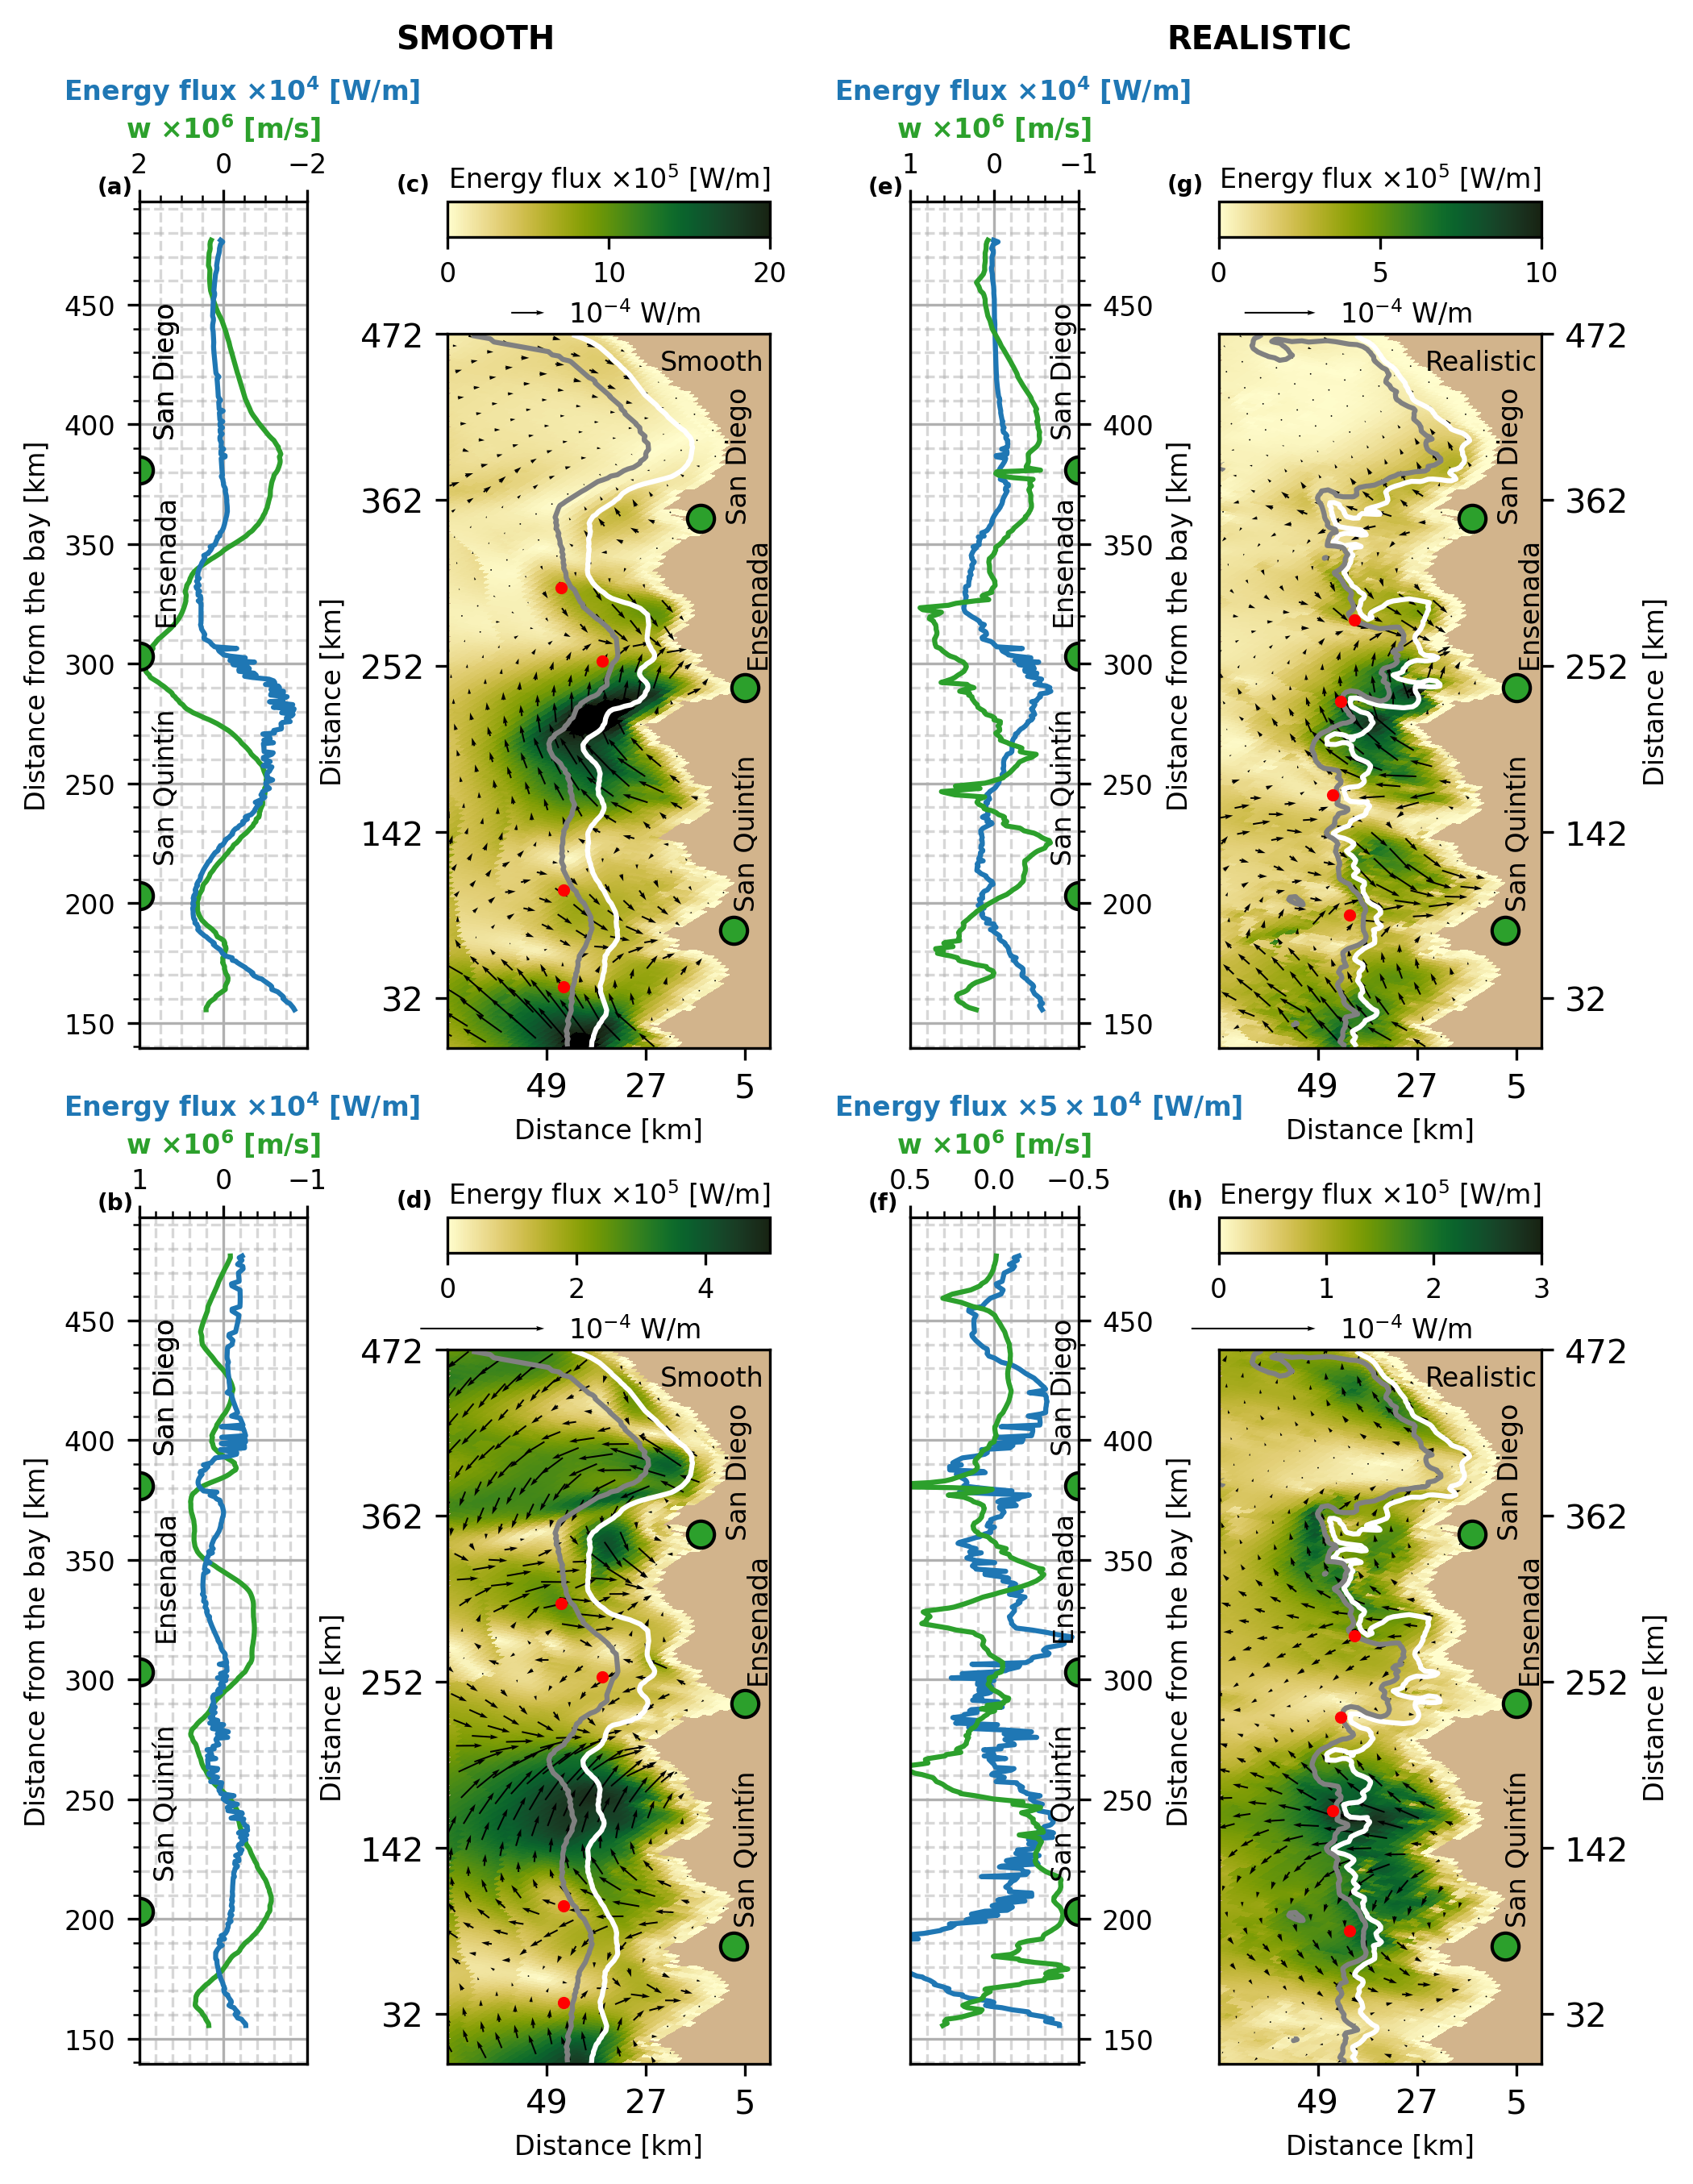

In [43]:
indstOrg=[1,3]
indstSmo=[1,4]
msG=8
msR=7
padi=0.4
clabel=r'Energy flux $\times 10^{5}$ [W/m]'


fig = plt.figure()
gs = GridSpec(nrows=2, ncols=10,wspace=10) #,wspace=0.3

for i in range(len(indstOrg)):
    k=indstSmo[i]
    ind0=indst[k]
    ind1=indst[k+1]
    
    kO=indstOrg[i]
    ind0O=indst[kO]
    ind1O=indst[kO+1]
    
    WVELin=np.mean(WVEL[ind0:ind1],axis=0)[startVel:endVel]
    WVELinOrg=np.mean(WVELOrg[ind0O:ind1O],axis=0)[startVelOrg:endVelOrg]
    
    fluxUw,fluxVw=timeIntegralW(ind0,ind1,dsU,dsV)
    fluxUn,fluxVn=timeIntegralN(ind0,ind1,dsU,dsV)
    OfluxUw,OfluxVw=timeIntegralW(ind0O,ind1O,dsUo,dsVo)
    OfluxUn,OfluxVn=timeIntegralN(ind0O,ind1O,dsUo,dsVo)

    #fluxU,fluxV=timeIntegral(ind0,ind1,dsU,dsV)
    #OfluxU,OfluxV=timeIntegral(ind0O,ind1O,dsUo,dsVo)

    fluxU=fluxUw-fluxUn
    fluxV=fluxVw-fluxVn
    OfluxU=OfluxUw-OfluxUn
    OfluxV=OfluxVw-OfluxVn
    
    if i==0:
        ylimWvel=2
        ylimWvelr=1
        vmin=0 #np.min(inarr[inarr!=0])
        vmax=20
        vminR=0 #np.min(inarr[inarr!=0])
        vmaxR=10
        fluxconst=1e4
        fluxconstr=1e4
        quivwidth=0.005
        quivscale=1.5*1e-3
        quivscaler=7*1e-4
    else:
        ylimWvel=1
        ylimWvelr=0.5
        vmin=0 #np.min(inarr[inarr!=0])
        vmax=5
        vminR=0 #np.min(inarr[inarr!=0])
        vmaxR=3
        fluxconst=1e4
        fluxconstr=5e4
        quivwidth=0.005
        quivscale=4*1e-4
        quivscaler=4*1e-4
    
    ax=fig.add_subplot(gs[i, 0:2])
    #ax.set_title(f'Day {i+2}-{i+3}',y=1.13)
    ax.plot(WVELin[:400]*1e6,distVEL[startVel:endVel][:400],color='tab:green')
    ax.set_xlim((-ylimWvel,ylimWvel))
    for ll, lab in zip(ind_latVel,
                       ['San Quintín', 'Ensenada', 'San Diego']):
        ax.plot(ylimWvel, distVEL[ll], 'o',markersize=msG, color='tab:green', markeredgecolor='k') # "|",markersize=20, color='green',zorder=5)
        ax.text(ylimWvel-ylimWvel/6, distVEL[ll]+15, lab, fontsize=8,color='black',rotation=90)
    
    ax.tick_params(axis='x',which='both', bottom=False,labelbottom=False,top=True,labeltop=True) 
    ax.xaxis.set_label_position("top")
    ax.minorticks_on()
    ax.set_ylabel('Distance from the bay [km]')
    ax.set_xlabel(r'w $\mathbf{\times 10^{6}}$ [m/s]',color='tab:green',fontweight='bold')
    ax.grid(which='minor',linestyle='--', alpha=0.5)
    ax.grid(which='major')
    if i==0:
        ax.text(-0.25, 1.01, '(a)', fontweight='bold', color='k', fontsize='small',
        transform=ax.transAxes)
    else:
        ax.text(-0.25, 1.01, '(b)', fontweight='bold', color='k', fontsize='small',
        transform=ax.transAxes)

    ax.plot(veltot[k][startVel:endVel][:400]*fluxconst,distVEL[startVel:endVel][:400],color='tab:blue')
    ax.text(ylimWvel-ylimWvel/6, distVEL[ll]+15, lab, fontsize=8,color='black',rotation=90)
    ax.text(-0.45, 1.12, r'Energy flux $\mathbf{\times 10^{4}}$ [W/m]', color='tab:blue',fontweight='bold',
        transform=ax.transAxes)
    ax.invert_xaxis()
        
    ax=fig.add_subplot(gs[ i,2:5])
    
    inarr1=np.ma.masked_array(np.sqrt((np.ma.masked_array(fluxU, mask=mask[0,:,:])/Tp)**2+(np.ma.masked_array(fluxV, mask=mask[0,:,:])/Tp)**2),mask=indarr)
    
    cmap=cmocean.cm.speed
    cmap.set_over('black')
    
    
    
    ax.set_facecolor('tan')
    
    cax1 = ax.pcolormesh(R2,R1,inarr1.T*1e5,vmin=vmin, vmax=vmax, cmap=cmap) 
    ax.contour(R2,R1,np.ma.masked_array(depth,mask=indarr).T, colors=[ 'white','gray'],
            levels=[200,500])
    #ax.contour(R1.T,R2.T,inarr,levels=[0])
    ax.scatter(lon_acVEL[maxpow]*sin(deg)+lat_acVEL[maxpow]*cos(deg),lon_acVEL[maxpow]*cos(deg)-lat_acVEL[maxpow]*sin(deg),color='red',zorder=4,label='Smooth',s=msR)
    
    divider = make_axes_locatable(ax)
    axdiv = divider.new_vertical(size = '5%', pad = padi)
    fig.add_axes(axdiv)
    cbar_ax = plt.colorbar(cax1, cax=axdiv,orientation='horizontal')
    cbar_ax.ax.xaxis.set_label_position("top")
    cbar_ax.set_label(clabel)
    
    ax.set_ylim((80.7,85))
    ax.set_xlim((87.95,88.6))
    #ax.tick_params(axis='x',which='both', bottom=True,labelbottom=False) 
    #ax.tick_params(axis='y',which='both', left=False,right=True, labelleft=False) 
    #ax.yaxis.set_label_position("right")
    ax.text(0.66,0.95, f'Smooth', transform=ax.transAxes,horizontalalignment='left',fontsize=8)
    
    spacex=5
    space=5
    
    gridXind=R1[np.arange(0,len(R2[:,0]),spacex),:]
    gridYind=R2[np.arange(0,len(R2[:,0]),spacex),:]
    Uind=np.ma.masked_array(np.ma.masked_array((fluxU/Tp), mask=mask[0,:,:]),mask=indarr)[:,np.arange(0,len(R2[:,0]),space)]
    Vind=np.ma.masked_array(np.ma.masked_array((fluxV/Tp), mask=mask[0,:,:]),mask=indarr)[:,np.arange(0,len(R2[:,0]),space)]
    
    q=ax.quiver(gridYind[:,np.arange(0,len(R2[0,:]),space)],gridXind[:,np.arange(0,len(R2[0,:]),space)],Uind[np.arange(0,len(R2[0,:]),spacex),:].T,Vind[np.arange(0,len(R2[0,:]),spacex),:].T,width=quivwidth,scale_units='xy', scale=quivscale)
    ax.quiverkey(q, X=0.3, Y=1.03, U=1e-4,
             label=r'$10^{-4}$ W/m', labelpos='E') 
    
    ax.set_yticks(np.arange(81,86,1))
    ax.set_yticklabels((110*(np.arange(81,86,1)-80.7)).astype(int), fontsize=10)
    
    ax.set_xticks(np.arange(88.0,88.6,0.2))
    ax.set_xticklabels((110*(np.arange(88,88.6,0.2)-87.95)).astype(int), fontsize=10)
    
    ax.set(xlabel='Distance [km]',ylabel='Distance [km]')
    
    ind_lon = [ -115.939167, -116.605833, -117.1625]
    ind_lat = [30.556389, 31.857778, 32.715]
    
    
    for kk, ll, lab in zip(ind_lon, ind_lat,
                       ['San Quintín', 'Ensenada', 'San Diego']):
        ax.plot(kk*sin(deg)+ll*cos(deg),kk*cos(deg)-ll*sin(deg), 'o',markersize=msG, color='tab:green', markeredgecolor='k',zorder=1)
        if lab =='San Quintín':
            ax.text(kk*sin(deg)+ll*cos(deg), kk*cos(deg)-ll*sin(deg)+0.15 , lab, fontsize=8,rotation=90)
        elif lab =='San Diego':
            ax.text(kk*sin(deg)+ll*cos(deg)-0.05 ,kk*cos(deg)-ll*sin(deg) ,  lab, fontsize=8,rotation=90)
        else:
            ax.text(kk*sin(deg)+ll*cos(deg) ,kk*cos(deg)-ll*sin(deg)+0.15 ,  lab, fontsize=8,rotation=90)
    
    if i==0:
        ax.text(-0.16, 1.2, '(c)', fontweight='bold', color='k', fontsize='small',
        transform=ax.transAxes)
    else:
        ax.text(-0.16, 1.2, '(d)', fontweight='bold', color='k', fontsize='small',
        transform=ax.transAxes)
    
    ax.invert_xaxis() 
    if i==0:
        ax.text(-0.16, 1.4, 'SMOOTH', fontweight='bold', color='k', fontsize='large',
        transform=ax.transAxes)
    
    ax=fig.add_subplot(gs[i,5:7])
    ax.plot(veltoto[k][startVel:endVel][:400]*fluxconstr,distVELOrg[startVelOrg:endVelOrg][:400],color='tab:blue')
    ax.plot(WVELinOrg[:400]*1e6,distVELOrg[startVelOrg:endVelOrg][:400],color='tab:green')
    ax.set_xlim((-ylimWvelr,ylimWvelr))
    for ll, lab in zip(ind_latVel,
                       ['San Quintín', 'Ensenada', 'San Diego']):
        ax.plot(-ylimWvelr,distVELOrg[ll], 'o',markersize=msG, color='tab:green', markeredgecolor='k') # "|",markersize=20, color='green',zorder=5)
        ax.text(-ylimWvelr+ylimWvelr/3,distVELOrg[ll]+15, lab, fontsize=8,color='black',rotation=90)
    #ax.text(300, ylimWvel+ylimWvel/6, 'Vertical Velocity [m/s]\nAverage over the period', fontsize=8,color='black')    
    ax.tick_params(axis='y',which='both', left=False,right=True, labelright=True,labelleft=False) 
    ax.yaxis.set_label_position("right")
    
    ax.tick_params(axis='x',which='both', bottom=False,labelbottom=False,top=True,labeltop=True) 
    ax.xaxis.set_label_position("top")
    ax.minorticks_on()
    ax.set_ylabel('Distance from the bay [km]')
    ax.set_xlabel(r'w $\mathbf{\times 10^{6}}$ [m/s]',color='tab:green',fontweight='bold')
    ax.grid(which='minor',linestyle='--', alpha=0.5)
    ax.grid(which='major')
    
    if i==0:
        ax.text(-0.25, 1.01, '(e)', fontweight='bold', color='k', fontsize='small',
        transform=ax.transAxes)
        ax.text(-0.45, 1.12, r'Energy flux $\mathbf{\times 10^{4}}$ [W/m]', color='tab:blue',fontweight='bold',
        transform=ax.transAxes)
    else:
        ax.text(-0.25, 1.01, '(f)', fontweight='bold', color='k', fontsize='small',
        transform=ax.transAxes)
        ax.text(-0.45, 1.12, r'Energy flux $\mathbf{\times5\times 10^{4}}$ [W/m]', color='tab:blue',fontweight='bold',
        transform=ax.transAxes)
    ax.invert_xaxis()


    
    ax=fig.add_subplot(gs[ i,7:])
    ax.tick_params(axis='y',which='both', left=False,right=True, labelright=True,labelleft=False) 
    ax.yaxis.set_label_position("right")
    ax.set_facecolor('tan')
    inarr=np.ma.masked_array(np.sqrt((np.ma.masked_array(OfluxU/Tp, mask=mask[0,:,:]))**2+(np.ma.masked_array(OfluxV/Tp, mask=mask[0,:,:]))**2),mask=indarr)

    ax.set_ylim((80.7,85))
    ax.set_xlim((87.95,88.6))
    
    ax.set_yticks(np.arange(81,86,1))
    ax.set_yticklabels((110*(np.arange(81,86,1)-80.7)).astype(int), fontsize=10)
    
    ax.set_xticks(np.arange(88.0,88.6,0.2))
    ax.set_xticklabels((110*(np.arange(88,88.6,0.2)-87.95)).astype(int), fontsize=10)
    
    ax.set(xlabel='Distance [km]',ylabel='Distance [km]')
    
    cax3 = ax.pcolormesh(R2,R1,inarr.T*1e5,vmin=vminR, vmax=vmaxR, cmap=cmap) 
    ax.contour(R2,R1,np.ma.masked_array(depthorg,mask=indarr).T, colors=[ 'white','gray'],
            levels=[200,500])
    spacex=5
    space=5
    
    divider = make_axes_locatable(ax)
    axdiv = divider.new_vertical(size = '5%', pad = padi)
    fig.add_axes(axdiv)
    cbar_ax = plt.colorbar(cax3, cax=axdiv,orientation='horizontal')
    cbar_ax.ax.xaxis.set_label_position("top")
    cbar_ax.set_label(clabel)
    
    
    gridXind=R1[np.arange(0,len(R2[:,0]),spacex),:]
    gridYind=R2[np.arange(0,len(R2[:,0]),spacex),:]
    Uindo=np.ma.masked_array(np.ma.masked_array((OfluxU/Tp), mask=mask[0,:,:]),mask=indarr)[:,np.arange(0,len(R2[:,0]),space)]
    Vindo=np.ma.masked_array(np.ma.masked_array((OfluxV/Tp), mask=mask[0,:,:]),mask=indarr)[:,np.arange(0,len(R2[:,0]),space)]
    
    q=ax.quiver(gridYind[:,np.arange(0,len(R2[0,:]),space)],gridXind[:,np.arange(0,len(R2[0,:]),space)],Uindo[np.arange(0,len(R2[0,:]),spacex),:].T,Vindo[np.arange(0,len(R2[0,:]),spacex),:].T,width=quivwidth,scale_units='xy', scale=quivscaler)
    
    ax.quiverkey(q, X=0.3, Y=1.03, U=1e-4,
             label=r'$10^{-4}$ W/m', labelpos='E') 
    
    ax.text(0.64,0.95, f'Realistic', transform=ax.transAxes,horizontalalignment='left',fontsize=8)
    
    ax.scatter(lon_acVEL[maxpowOrg]*sin(deg)+lat_acVEL[maxpowOrg]*cos(deg),lon_acVEL[maxpowOrg]*cos(deg)-lat_acVEL[maxpowOrg]*sin(deg),color='red',zorder=4,label='Original',s=msR)
    
    
    ind_lon = [ -115.939167, -116.605833, -117.1625]
    ind_lat = [30.556389, 31.857778, 32.715]
    
    
    for kk, ll, lab in zip(ind_lon, ind_lat,
                       ['San Quintín', 'Ensenada', 'San Diego']):
        ax.plot(kk*sin(deg)+ll*cos(deg),kk*cos(deg)-ll*sin(deg), 'o',markersize=msG, color='tab:green', markeredgecolor='k',zorder=1)
        if lab =='San Quintín':
            ax.text(kk*sin(deg)+ll*cos(deg), kk*cos(deg)-ll*sin(deg)+0.15 , lab, fontsize=8,rotation=90)
        elif lab =='San Diego':
            ax.text(kk*sin(deg)+ll*cos(deg)-0.05 ,kk*cos(deg)-ll*sin(deg) ,  lab, fontsize=8,rotation=90)
        else:
            ax.text(kk*sin(deg)+ll*cos(deg) ,kk*cos(deg)-ll*sin(deg)+0.15 ,  lab, fontsize=8,rotation=90)
    if i==0:
        ax.text(-0.16, 1.2, '(g)', fontweight='bold', color='k', fontsize='small',
        transform=ax.transAxes)
    else:
        ax.text(-0.16, 1.2, '(h)', fontweight='bold', color='k', fontsize='small',
        transform=ax.transAxes)
    
    ax.invert_xaxis() 
    if i==0:
        ax.text(-0.16, 1.4, 'REALISTIC', fontweight='bold', color='k', fontsize='large',
        transform=ax.transAxes)
#fig.tight_layout()
#plt.savefig('../figures/EFLUX_fig7.pdf', bbox_inches='tight')